In [3]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


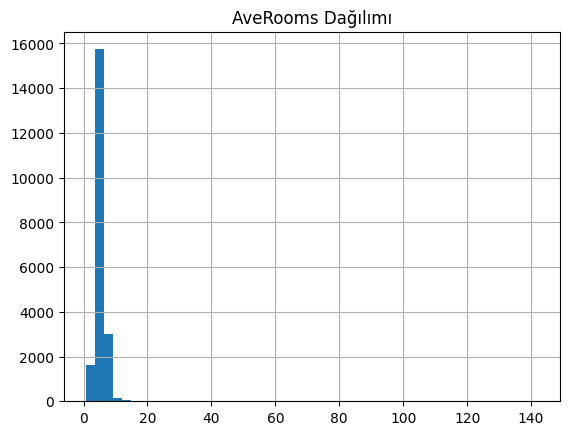

In [7]:
import matplotlib.pyplot as plt

df['AveRooms'].hist(bins=50)
plt.title('AveRooms Dağılımı')
plt.show()

In [8]:
print(f"Temizlik öncesi satır sayısı: {len(df)}")

df_clean = df[(df['AveRooms'] < 20) & (df['AveOccup'] < 10)]

print(f"Temizlik sonrası satır sayısı: {len(df_clean)}")

Temizlik öncesi satır sayısı: 20640
Temizlik sonrası satır sayısı: 20535


In [9]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


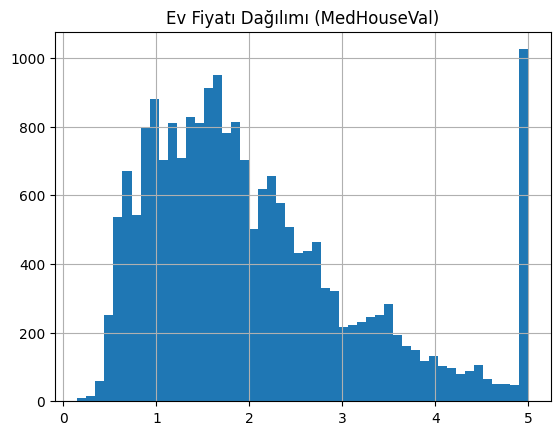

In [10]:
df_clean['MedHouseVal'].hist(bins=50)
plt.title('Ev Fiyatı Dağılımı (MedHouseVal)')
plt.show()

In [11]:
print(f"Öncesi: {len(df_clean)}")
df_clean = df_clean[df_clean['MedHouseVal'] < 5.0]
print(f"Sonrası: {len(df_clean)}")


Öncesi: 20535
Sonrası: 19548


In [12]:
correlation = df_clean.corr()['MedHouseVal'].sort_values(ascending=False)
print(correlation)

MedHouseVal    1.000000
MedInc         0.648425
AveRooms       0.203733
HouseAge       0.064722
Population     0.013099
Longitude     -0.045563
AveBedrms     -0.105662
Latitude      -0.149192
AveOccup      -0.242839
Name: MedHouseVal, dtype: float64


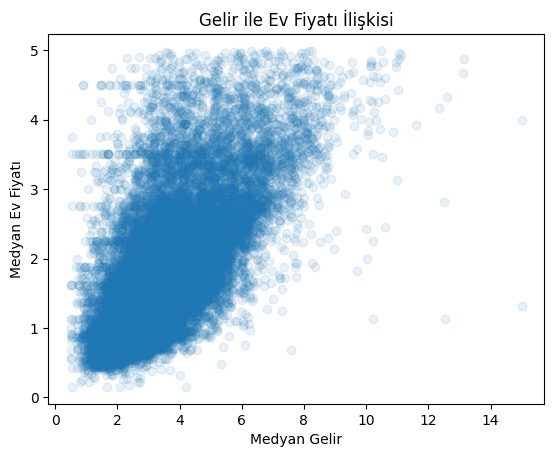

In [17]:
plt.scatter(df_clean['MedInc'], df_clean['MedHouseVal'], alpha=0.1)
plt.xlabel('Medyan Gelir')
plt.ylabel('Medyan Ev Fiyatı')
plt.title('Gelir ile Ev Fiyatı İlişkisi')
plt.show()

In [18]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['MedHouseVal'])
y = df_clean['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Eğitim seti boyutu: {X_train.shape}")
print(f"Test seti boyutu: {X_test.shape}")


Eğitim seti boyutu: (15638, 8)
Test seti boyutu: (3910, 8)


In [19]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Model eğitildi!")


Model eğitildi!


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Ortalama Mutlak Hata (MAE): {mae:.3f}")
print(f"R² Skoru: {r2:.3f}")

Ortalama Mutlak Hata (MAE): 0.441
R² Skoru: 0.636


In [21]:
import numpy as np

baseline_pred = np.full_like(y_test, y_train.mean())
baseline_mae = mean_absolute_error(y_test, baseline_pred)

print(f"Baseline (ortalama tahmin) MAE: {baseline_mae:.3f}")
print(f"Bizim model MAE: {mae:.3f}")


Baseline (ortalama tahmin) MAE: 0.798
Bizim model MAE: 0.441
